# P1 / P2 Protograph Training (tc01)

This notebook builds protographs from the synthetic ontology and trains class embeddings with [jRDF2Vec](https://github.com/dwslab/jRDF2Vec).

**Pipeline**
1. **P1** — one triple per property: `DomainClass --relation--> RangeClass`
2. **P2** — P1 plus direct subclass expansion: `(C'i, r, Cj)` and `(Ci, r, C'j)`
3. **Embed** — run jRDF2Vec on each `.nt` file (`-graph`, `-walkDirectory`, `-numberOfWalks`, `-depth`, `-dimension`)

**Prerequisites:** Java 8+, Python 3 with gensim (for the jRDF2Vec server). Verify setup with:
`java -jar jrdf2vec-1.3-SNAPSHOT_seed.jar -checkInstallation`

In [29]:
from pathlib import Path
import subprocess

from build_protographs import (
    parse_ontology_nt,
    build_indices,
    build_prototype_v1,
    build_prototype_v2,
)

ROOT = Path(".").resolve()
TC = 7
TC_STR = f"tc{TC:02d}"

ONTOLOGY = ROOT / "v1/synthetic_ontology" / TC_STR / "synthetic_ontology" / "ontology.nt"
PROTO_DIR = ROOT / "training_output/synthetic_ontology" / TC_STR / "protographs"
JAR = ROOT / "jrdf2vec-1.3-SNAPSHOT_seed.jar"

# jRDF2Vec settings (match embed_protograph.py)
NUM_WALKS, DEPTH, DIM = 200, 3, 200

assert ONTOLOGY.exists(), f"Ontology not found: {ONTOLOGY}"
assert JAR.exists(), f"jRDF2Vec JAR not found: {JAR}"

print(f"ROOT:     {ROOT}")
print(f"Ontology: {ONTOLOGY}")
print(f"Output:   {PROTO_DIR}")
print(f"JAR:      {JAR}")

ROOT:     /Users/bagautdinnukhkadiev/RDF2Vec_pretrain
Ontology: /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/v1/synthetic_ontology/tc07/synthetic_ontology/ontology.nt
Output:   /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/protographs
JAR:      /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/jrdf2vec-1.3-SNAPSHOT_seed.jar


In [30]:
triples = parse_ontology_nt(ONTOLOGY)
rel2domain, rel2range, class2subclasses = build_indices(triples)
PROTO_DIR.mkdir(parents=True, exist_ok=True)

build_prototype_v1(rel2domain, rel2range, PROTO_DIR / "protograph_p1.nt")
build_prototype_v2(rel2domain, rel2range, class2subclasses, PROTO_DIR / "protograph_p2.nt")

[P1] wrote /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/protographs/protograph_p1.nt (1355 triples)
[P2] wrote /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/protographs/protograph_p2.nt (10425 triples)


In [31]:
for proto in ("p1", "p2"):
    graph = PROTO_DIR / f"protograph_{proto}.nt"
    out_dir = PROTO_DIR / proto
    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        "java", "-jar", str(JAR),
        "-graph", str(graph),
        "-walkDirectory", str(out_dir),
        "-numberOfWalks", str(NUM_WALKS),
        "-depth", str(DEPTH),
        "-dimension", str(DIM),
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)
    print(f"[OK] {proto} -> {out_dir}\n")

Running: java -jar /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/jrdf2vec-1.3-SNAPSHOT_seed.jar -graph /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/protographs/protograph_p1.nt -walkDirectory /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/protographs/p1 -numberOfWalks 200 -depth 3 -dimension 200
Using server port: 1808
Using 4 threads for walk generation and training.
Using vector dimension: 200
Using depth 3
Generating 200 walks per entity.
RDF2Vec Classic
08 Jun 2026 22:14:49  INFO [main] (WalkGeneratorManager.java:64) - Using NxParser.
08 Jun 2026 22:14:49  INFO [main] (WalkGeneratorManager.java:99) - Model read into memory.
08 Jun 2026 22:14:49  INFO [main] (RDF2Vec.java:206) - Walks successfully generated. Starting training now...
08 Jun 2026 22:14:49  INFO [main] (Gensim.java:734) - Python command file detected.
08 Jun 2026 22:14:49 DEBUG [main] (RequestAddCookies.java:123) - CookieSpec selected: default
08

/Users/bagautdinnukhkadiev/RDF2Vec_pretrain/python-server/python_server.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


 * Serving Flask app 'python_server'
 * Debug mode: off
08 Jun 2026 22:14:59 DEBUG [main] (PoolingHttpClientConnectionManager.java:411) - Connection manager is shutting down
08 Jun 2026 22:14:59 DEBUG [main] (PoolingHttpClientConnectionManager.java:434) - Connection manager shut down
08 Jun 2026 22:14:59 DEBUG [main] (RequestAddCookies.java:123) - CookieSpec selected: default
08 Jun 2026 22:14:59 DEBUG [main] (RequestAuthCache.java:77) - Auth cache not set in the context
08 Jun 2026 22:14:59 DEBUG [main] (PoolingHttpClientConnectionManager.java:267) - Connection request: [route: {}->http://127.0.0.1:1808][total available: 0; route allocated: 0 of 2; total allocated: 0 of 20]
08 Jun 2026 22:14:59 DEBUG [main] (PoolingHttpClientConnectionManager.java:312) - Connection leased: [id: 1][route: {}->http://127.0.0.1:1808][total available: 0; route allocated: 1 of 2; total allocated: 1 of 20]
08 Jun 2026 22:14:59 DEBUG [main] (MainClientExec.java:234) - Opening connection {}->http://127.0.0.1:

/Users/bagautdinnukhkadiev/RDF2Vec_pretrain/python-server/python_server.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


 * Serving Flask app 'python_server'
 * Debug mode: off
08 Jun 2026 22:16:49 DEBUG [main] (PoolingHttpClientConnectionManager.java:411) - Connection manager is shutting down
08 Jun 2026 22:16:49 DEBUG [main] (PoolingHttpClientConnectionManager.java:434) - Connection manager shut down
08 Jun 2026 22:16:49 DEBUG [main] (RequestAddCookies.java:123) - CookieSpec selected: default
08 Jun 2026 22:16:49 DEBUG [main] (RequestAuthCache.java:77) - Auth cache not set in the context
08 Jun 2026 22:16:49 DEBUG [main] (PoolingHttpClientConnectionManager.java:267) - Connection request: [route: {}->http://127.0.0.1:1808][total available: 0; route allocated: 0 of 2; total allocated: 0 of 20]
08 Jun 2026 22:16:49 DEBUG [main] (PoolingHttpClientConnectionManager.java:312) - Connection leased: [id: 1][route: {}->http://127.0.0.1:1808][total available: 0; route allocated: 1 of 2; total allocated: 1 of 20]
08 Jun 2026 22:16:49 DEBUG [main] (MainClientExec.java:234) - Opening connection {}->http://127.0.0.1:

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


08 Jun 2026 22:17:20 DEBUG [main] (Wire.java:73) - http-outgoing-2 << "HTTP/1.1 200 OK[\r][\n]"
08 Jun 2026 22:17:20 DEBUG [main] (Wire.java:73) - http-outgoing-2 << "Server: Werkzeug/2.2.0 Python/3.13.0[\r][\n]"
08 Jun 2026 22:17:20 DEBUG [main] (Wire.java:73) - http-outgoing-2 << "Date: Mon, 08 Jun 2026 20:17:20 GMT[\r][\n]"
08 Jun 2026 22:17:20 DEBUG [main] (Wire.java:73) - http-outgoing-2 << "Content-Type: text/html; charset=utf-8[\r][\n]"
08 Jun 2026 22:17:20 DEBUG [main] (Wire.java:73) - http-outgoing-2 << "Content-Length: 4[\r][\n]"
08 Jun 2026 22:17:20 DEBUG [main] (Wire.java:73) - http-outgoing-2 << "Connection: close[\r][\n]"
08 Jun 2026 22:17:20 DEBUG [main] (Wire.java:73) - http-outgoing-2 << "[\r][\n]"
08 Jun 2026 22:17:20 DEBUG [main] (LoggingManagedHttpClientConnection.java:122) - http-outgoing-2 << HTTP/1.1 200 OK
08 Jun 2026 22:17:20 DEBUG [main] (LoggingManagedHttpClientConnection.java:125) - http-outgoing-2 << Server: Werkzeug/2.2.0 Python/3.13.0
08 Jun 2026 22:17:20

In [32]:
from gensim.models import KeyedVectors

for proto in ("p1", "p2"):
    out_dir = PROTO_DIR / proto
    kv_path = out_dir / "model.kv"

    print(f"=== {proto} ===")
    print("Files:", sorted(p.name for p in out_dir.iterdir()))
    assert kv_path.exists(), f"Missing model.kv: {kv_path}"

    kv = KeyedVectors.load(str(kv_path), mmap=None)
    print(f"model.kv: {len(kv)} tokens, dim={kv.vector_size}\n")

2026-06-08 22:18:43,915 INFO: loading KeyedVectors object from /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/protographs/p1/model.kv


=== p1 ===
Files: ['model', 'model.kv', 'model.kv.vectors.npy', 'model.syn1neg.npy', 'model.wv.vectors.npy', 'vectors.txt', 'walk_file_0.txt.gz']


2026-06-08 22:18:44,157 INFO: loading vectors from /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/protographs/p1/model.kv.vectors.npy with mmap=None
2026-06-08 22:18:44,332 INFO: KeyedVectors lifecycle event {'fname': '/Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/protographs/p1/model.kv', 'datetime': '2026-06-08T22:18:44.332299', 'gensim': '4.4.0', 'python': '3.13.0 (v3.13.0:60403a5409f, Oct  7 2024, 00:37:40) [Clang 15.0.0 (clang-1500.3.9.4)]', 'platform': 'macOS-15.7.1-arm64-arm-64bit-Mach-O', 'event': 'loaded'}
2026-06-08 22:18:44,347 INFO: loading KeyedVectors object from /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/protographs/p2/model.kv
2026-06-08 22:18:44,508 INFO: loading vectors from /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/protographs/p2/model.kv.vectors.npy with mmap=None


model.kv: 335363 tokens, dim=200

=== p2 ===
Files: ['model', 'model.kv', 'model.kv.vectors.npy', 'model.syn1neg.npy', 'model.wv.vectors.npy', 'vectors.txt', 'walk_file_0.txt.gz']


2026-06-08 22:18:44,782 INFO: KeyedVectors lifecycle event {'fname': '/Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/protographs/p2/model.kv', 'datetime': '2026-06-08T22:18:44.781444', 'gensim': '4.4.0', 'python': '3.13.0 (v3.13.0:60403a5409f, Oct  7 2024, 00:37:40) [Clang 15.0.0 (clang-1500.3.9.4)]', 'platform': 'macOS-15.7.1-arm64-arm-64bit-Mach-O', 'event': 'loaded'}


model.kv: 401683 tokens, dim=200



## Instance graph finetuning (tc01)

Finetune the protograph embeddings on **instance-graph walks** from `all_walks/tc01`.

**Pipeline**
1. Build `entity2classes.json` from the ontology via `mapping_all_entities.py` (most-specific declared `rdf:type` classes per instance).
2. For each protograph variant (**p1**, **p2**):
   - Load protograph `model.kv` (class vectors).
   - Build a fresh Word2Vec vocab from instance walks.
   - Initialize instance vectors by averaging their class vectors.
   - Train on instance walks for several epochs (checkpoints saved per epoch).

In [33]:
import json

from mapping_all_entities import (
    parse_ontology_nt,
    build_ancestor_index,
    most_specific_declared,
)

INSTANCE_WALKS = ROOT / "all_walks" / TC_STR
MAPPING_PATH = ROOT / "training_output/synthetic_ontology" / TC_STR / "entity2classes.json"
FINETUNE_BASE = ROOT / "training_output/synthetic_ontology" / TC_STR / "walks" / "instance_finetune"
GRAPH_EPOCHS = 5

assert INSTANCE_WALKS.exists(), f"Instance walks not found: {INSTANCE_WALKS}"
assert any(p.name.endswith(".gz") for p in INSTANCE_WALKS.iterdir()), f"No .gz walk files in {INSTANCE_WALKS}"

instance_types, class_parents = parse_ontology_nt(ONTOLOGY)
ancestors = build_ancestor_index(class_parents)
entity2classes = {
    inst: most_specific_declared(declared, ancestors)
    for inst, declared in sorted(instance_types.items())
}

MAPPING_PATH.parent.mkdir(parents=True, exist_ok=True)
MAPPING_PATH.write_text(json.dumps(entity2classes, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Instance walks: {INSTANCE_WALKS}")
print(f"Walk files:     {sorted(p.name for p in INSTANCE_WALKS.iterdir() if p.name.endswith('.gz'))}")
print(f"entity2classes: {MAPPING_PATH} ({len(entity2classes)} instances)")
print(f"Finetune out:   {FINETUNE_BASE}/{{p1,p2}}")
print(f"Graph epochs:   {GRAPH_EPOCHS}")

[INFO] Parsed 11929 instances and 759 subclass edges from /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/v1/synthetic_ontology/tc07/synthetic_ontology/ontology.nt
Instance walks: /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/all_walks/tc07
Walk files:     ['walk_file_0.txt.gz']
entity2classes: /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/entity2classes.json (11929 instances)
Finetune out:   /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/instance_finetune/{p1,p2}
Graph epochs:   5


In [34]:
import logging
import os
import time

from gensim.models import KeyedVectors, Word2Vec

from resume_graph_train import (
    CheckpointSaver,
    MySentences,
    ReiterableGraphWalks,
    init_instance_vectors_from_classes_instance_only,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("instance_finetune")


def finetune_on_instance_walks(proto: str, graph_epochs: int = GRAPH_EPOCHS) -> Path:
    proto_kv_path = PROTO_DIR / proto / "model.kv"
    out_dir = FINETUNE_BASE / proto
    workers = os.cpu_count() or 1

    assert proto_kv_path.exists(), f"Protograph KV not found: {proto_kv_path}"

    out_dir.mkdir(parents=True, exist_ok=True)
    logger.info("=== Finetune %s from %s on %s ===", proto, proto_kv_path, INSTANCE_WALKS)

    proto_kv: KeyedVectors = KeyedVectors.load(str(proto_kv_path), mmap=None)

    sentences_for_vocab = MySentences(INSTANCE_WALKS)
    model = Word2Vec(
        vector_size=proto_kv.vector_size,
        window=5,
        sg=1,
        hs=0,
        negative=5,
        min_count=1,
        sample=0.0,
        workers=workers,
        compute_loss=True,
        seed=42,
    )
    model.build_vocab(sentences_for_vocab)
    vocab_size = len(model.wv)
    graph_count = model.corpus_count
    logger.info("Vocab size: %d, corpus count: %d", vocab_size, graph_count)

    inst2classes_raw = json.loads(MAPPING_PATH.read_text(encoding="utf-8"))
    initialized, skipped_nv, skipped_nc, skipped_bad = init_instance_vectors_from_classes_instance_only(
        model, proto_kv, inst2classes_raw
    )
    logger.info(
        "Init from classes: initialized=%d | skipped_not_in_vocab=%d | skipped_no_classvec=%d | skipped_bad=%d",
        initialized, skipped_nv, skipped_nc, skipped_bad,
    )

    init_stats = {
        "vocab_size": vocab_size,
        "initialized": initialized,
        "skipped_not_in_vocab": skipped_nv,
        "skipped_no_classvec": skipped_nc,
        "skipped_bad": skipped_bad,
    }

    init_dir = out_dir / "epoch_0"
    init_dir.mkdir(parents=True, exist_ok=True)
    model.save(str(init_dir / "model.model"))
    model.wv.save(str(init_dir / "model.kv"))
    logger.info("Saved init checkpoint: %s", init_dir)

    metadata_rows: list[dict] = []
    corpus = ReiterableGraphWalks(INSTANCE_WALKS)
    checkpoint_cb = CheckpointSaver(out_dir, save_each_epoch=True, metadata_rows=metadata_rows, init_stats=init_stats)

    t0 = time.perf_counter()
    model.train(
        corpus,
        total_examples=graph_count,
        epochs=graph_epochs,
        callbacks=[checkpoint_cb],
        compute_loss=True,
    )
    logger.info("Training done in %.2fs", time.perf_counter() - t0)

    meta = {
        "tc": TC_STR,
        "proto": proto,
        "instance_walks_path": str(INSTANCE_WALKS),
        "graph_corpus_count": graph_count,
        "graph_epochs": graph_epochs,
        **init_stats,
        "epochs": metadata_rows,
    }
    (out_dir / "epochs_metadata.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
    return out_dir


for proto in ("p1", "p2"):
    out = finetune_on_instance_walks(proto)
    print(f"[OK] {proto} -> {out}\n")

2026-06-08 22:18:45,046 INFO: === Finetune p1 from /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/protographs/p1/model.kv on /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/all_walks/tc07 ===
2026-06-08 22:18:45,047 INFO: loading KeyedVectors object from /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/protographs/p1/model.kv
2026-06-08 22:18:45,103 INFO: loading vectors from /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/protographs/p1/model.kv.vectors.npy with mmap=None
2026-06-08 22:18:45,272 INFO: KeyedVectors lifecycle event {'fname': '/Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/protographs/p1/model.kv', 'datetime': '2026-06-08T22:18:45.272897', 'gensim': '4.4.0', 'python': '3.13.0 (v3.13.0:60403a5409f, Oct  7 2024, 00:37:40) [Clang 15.0.0 (clang-1500.3.9.4)]', 'platform': 'macOS-15.7.1-arm64-arm-64bit-Mach-O', 'event': 'loaded'}
2026-06-

[OK] p1 -> /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/instance_finetune/p1



2026-06-08 22:19:32,799 INFO: KeyedVectors lifecycle event {'fname': '/Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/protographs/p2/model.kv', 'datetime': '2026-06-08T22:19:32.799356', 'gensim': '4.4.0', 'python': '3.13.0 (v3.13.0:60403a5409f, Oct  7 2024, 00:37:40) [Clang 15.0.0 (clang-1500.3.9.4)]', 'platform': 'macOS-15.7.1-arm64-arm-64bit-Mach-O', 'event': 'loaded'}
2026-06-08 22:19:32,804 INFO: Word2Vec lifecycle event {'params': 'Word2Vec<vocab=0, vector_size=200, alpha=0.025>', 'datetime': '2026-06-08T22:19:32.804658', 'gensim': '4.4.0', 'python': '3.13.0 (v3.13.0:60403a5409f, Oct  7 2024, 00:37:40) [Clang 15.0.0 (clang-1500.3.9.4)]', 'platform': 'macOS-15.7.1-arm64-arm-64bit-Mach-O', 'event': 'created'}
2026-06-08 22:19:32,804 INFO: collecting all words and their counts
2026-06-08 22:19:32,808 INFO: PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-06-08 22:19:32,819 INFO: PROGRESS: at sentence #10000, processed 69648 wo

[OK] p2 -> /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/instance_finetune/p2



In [35]:
for proto in ("p1", "p2"):
    out_dir = FINETUNE_BASE / proto
    final_kv = out_dir / f"epoch_{GRAPH_EPOCHS}" / "model.kv"

    print(f"=== {proto} finetuned ===")
    print("Checkpoints:", sorted(d.name for d in out_dir.iterdir() if d.is_dir()))
    assert final_kv.exists(), f"Missing final checkpoint: {final_kv}"

    kv = KeyedVectors.load(str(final_kv), mmap=None)
    print(f"epoch_{GRAPH_EPOCHS}/model.kv: {len(kv)} tokens, dim={kv.vector_size}")

    meta = json.loads((out_dir / "epochs_metadata.json").read_text(encoding="utf-8"))
    print(
        f"initialized={meta['initialized']}/{meta['vocab_size']} instances from protograph classes\n"
    )

2026-06-08 22:20:17,186 INFO: loading KeyedVectors object from /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/instance_finetune/p1/epoch_5/model.kv
2026-06-08 22:20:17,196 INFO: KeyedVectors lifecycle event {'fname': '/Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/instance_finetune/p1/epoch_5/model.kv', 'datetime': '2026-06-08T22:20:17.196437', 'gensim': '4.4.0', 'python': '3.13.0 (v3.13.0:60403a5409f, Oct  7 2024, 00:37:40) [Clang 15.0.0 (clang-1500.3.9.4)]', 'platform': 'macOS-15.7.1-arm64-arm-64bit-Mach-O', 'event': 'loaded'}
2026-06-08 22:20:17,221 INFO: loading KeyedVectors object from /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/instance_finetune/p2/epoch_5/model.kv
2026-06-08 22:20:17,225 INFO: KeyedVectors lifecycle event {'fname': '/Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/instance_finetune/p2/epoch_5

=== p1 finetuned ===
Checkpoints: ['epoch_0', 'epoch_1', 'epoch_2', 'epoch_3', 'epoch_4', 'epoch_5']
epoch_5/model.kv: 12845 tokens, dim=200
initialized=6186/12845 instances from protograph classes

=== p2 finetuned ===
Checkpoints: ['epoch_0', 'epoch_1', 'epoch_2', 'epoch_3', 'epoch_4', 'epoch_5']
epoch_5/model.kv: 12845 tokens, dim=200
initialized=10566/12845 instances from protograph classes



## Vanilla baseline (tc01)

Train a standard Word2Vec model from scratch on the same instance walks (`all_walks/tc01`), using the same hyperparameters and training loop as `train_like_jrdf2vec_server.py` (jRDF2Vec Python server parity).

In [36]:
from argparse import Namespace

from train_like_jrdf2vec_server import run_one

VANILLA_OUT = ROOT / "training_output/synthetic_ontology" / TC_STR / "walks" / "vanilla_epochwise"
VANILLA_OUT.mkdir(parents=True, exist_ok=True)

vanilla_args = Namespace(
    number_of_threads=None,
    hierarchical_softmax="false",
    iterations=1,
    epochs=GRAPH_EPOCHS,
    vector_dimension=DIM,
    window_size=5,
    cbow_or_sg="sg",
    negatives=5,
    min_count=1,
    sample=0.0,
    save_epoch0=True,
    save_each_epoch=True,
)

print(f"Instance walks: {INSTANCE_WALKS}")
print(f"Vanilla out:    {VANILLA_OUT}")
print(f"Epochs:         {GRAPH_EPOCHS}")

run_one(
    walks_path=INSTANCE_WALKS,
    model_path=VANILLA_OUT / "model.model",
    vector_path=VANILLA_OUT / "model.kv",
    args=vanilla_args,
)
print(f"[OK] vanilla -> {VANILLA_OUT}")

2026-06-08 22:20:17,231 INFO: Sentences object (/Users/bagautdinnukhkadiev/RDF2Vec_pretrain/all_walks/tc07) initialized.
2026-06-08 22:20:17,231 INFO: hs: 0
2026-06-08 22:20:17,231 INFO: iterations=1 (Word2Vec constructor default), epochs=5 (used in model.train; this is the actual training length).
2026-06-08 22:20:17,232 INFO: Training config: dim=200 window=5 sg=sg negative=5 min_count=1 sample=0.0 workers=8 hs=0 iterations=1 train_epochs=5
2026-06-08 22:20:17,232 INFO: Word2Vec lifecycle event {'params': 'Word2Vec<vocab=0, vector_size=200, alpha=0.025>', 'datetime': '2026-06-08T22:20:17.232514', 'gensim': '4.4.0', 'python': '3.13.0 (v3.13.0:60403a5409f, Oct  7 2024, 00:37:40) [Clang 15.0.0 (clang-1500.3.9.4)]', 'platform': 'macOS-15.7.1-arm64-arm-64bit-Mach-O', 'event': 'created'}
2026-06-08 22:20:17,232 INFO: Model object initialized. Building Vocabulary...
2026-06-08 22:20:17,232 INFO: collecting all words and their counts
2026-06-08 22:20:17,233 INFO: Directory detected.
2026-06-

Instance walks: /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/all_walks/tc07
Vanilla out:    /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/vanilla_epochwise
Epochs:         5


2026-06-08 22:20:17,372 INFO: PROGRESS: at sentence #140000, processed 975030 words, keeping 12371 word types
2026-06-08 22:20:17,382 INFO: PROGRESS: at sentence #150000, processed 1044674 words, keeping 12400 word types
2026-06-08 22:20:17,392 INFO: PROGRESS: at sentence #160000, processed 1114300 words, keeping 12432 word types
2026-06-08 22:20:17,402 INFO: PROGRESS: at sentence #170000, processed 1183958 words, keeping 12457 word types
2026-06-08 22:20:17,412 INFO: PROGRESS: at sentence #180000, processed 1253626 words, keeping 12475 word types
2026-06-08 22:20:17,423 INFO: PROGRESS: at sentence #190000, processed 1323298 words, keeping 12494 word types
2026-06-08 22:20:17,433 INFO: PROGRESS: at sentence #200000, processed 1392904 words, keeping 12502 word types
2026-06-08 22:20:17,443 INFO: PROGRESS: at sentence #210000, processed 1462568 words, keeping 12505 word types
2026-06-08 22:20:17,453 INFO: PROGRESS: at sentence #220000, processed 1532178 words, keeping 12516 word types
20

[OK] vanilla -> /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/vanilla_epochwise


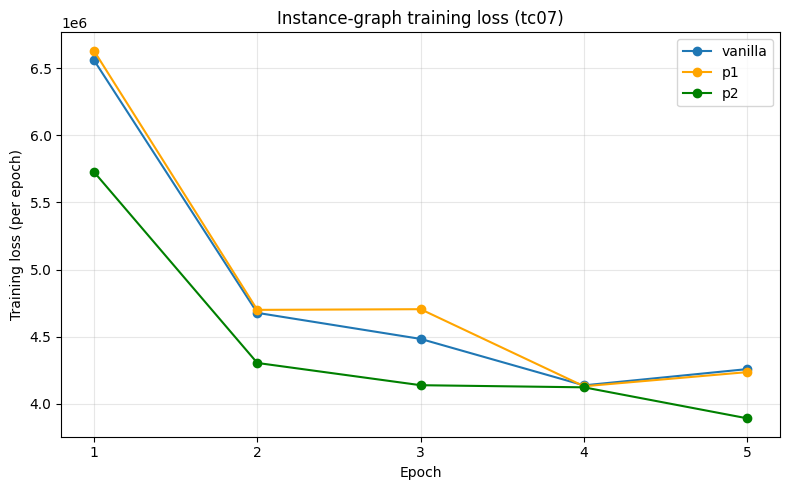

In [37]:
import matplotlib.pyplot as plt


def load_training_losses(meta_path: Path) -> tuple[list[int], list[float]]:
    meta = json.loads(meta_path.read_text(encoding="utf-8"))
    epochs, losses = [], []
    for row in meta["epochs"]:
        loss = row.get("loss")
        epoch = row.get("graph_epoch", row.get("epoch"))
        if loss is not None and epoch is not None and epoch > 0:
            epochs.append(epoch)
            losses.append(loss)
    return epochs, losses


loss_curves = {
    "vanilla": VANILLA_OUT / "epochs_metadata.json",
    "p1": FINETUNE_BASE / "p1" / "epochs_metadata.json",
    "p2": FINETUNE_BASE / "p2" / "epochs_metadata.json",
}
colors = {"vanilla": "C0", "p1": "orange", "p2": "green"}  # C0 = matplotlib default light blue

fig, ax = plt.subplots(figsize=(8, 5))
for label, meta_path in loss_curves.items():
    assert meta_path.exists(), f"Missing metadata: {meta_path}"
    epochs, losses = load_training_losses(meta_path)
    ax.plot(epochs, losses, marker="o", label=label, color=colors[label])

ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss (per epoch)")
ax.set_title(f"Instance-graph training loss ({TC_STR})")
ax.set_xticks(range(1, GRAPH_EPOCHS + 1))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Test-set accuracy per epoch

Evaluate each epoch checkpoint on the held-out test set from `v1/synthetic_ontology/{tc}/synthetic_ontology/1000/train_test/`.

For every checkpoint (`epoch_0` … `epoch_{GRAPH_EPOCHS}`):
1. Load instance embeddings from `model.kv`.
2. Train logistic regression on the train split (same folder).
3. Report accuracy on the test split.

2026-06-08 22:21:13,935 INFO: loading KeyedVectors object from /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/vanilla_epochwise/epoch_0/model.kv
2026-06-08 22:21:13,948 INFO: KeyedVectors lifecycle event {'fname': '/Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/vanilla_epochwise/epoch_0/model.kv', 'datetime': '2026-06-08T22:21:13.948908', 'gensim': '4.4.0', 'python': '3.13.0 (v3.13.0:60403a5409f, Oct  7 2024, 00:37:40) [Clang 15.0.0 (clang-1500.3.9.4)]', 'platform': 'macOS-15.7.1-arm64-arm-64bit-Mach-O', 'event': 'loaded'}
2026-06-08 22:21:13,964 INFO: loading KeyedVectors object from /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/vanilla_epochwise/epoch_1/model.kv
2026-06-08 22:21:13,974 INFO: KeyedVectors lifecycle event {'fname': '/Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/vanilla_epochwise/epoch_1/model.kv', 


=== vanilla ===
vanilla_epochwise epoch 0: acc=0.5325 (400/400 in vocab)
vanilla_epochwise epoch 1: acc=0.5575 (400/400 in vocab)
vanilla_epochwise epoch 2: acc=0.5650 (400/400 in vocab)
vanilla_epochwise epoch 3: acc=0.5700 (400/400 in vocab)
vanilla_epochwise epoch 4: acc=0.5750 (400/400 in vocab)
vanilla_epochwise epoch 5: acc=0.5725 (400/400 in vocab)

=== p1 ===
     p1 epoch 0: acc=0.4825 (400/400 in vocab)
     p1 epoch 1: acc=0.5500 (400/400 in vocab)
     p1 epoch 2: acc=0.5600 (400/400 in vocab)
     p1 epoch 3: acc=0.6000 (400/400 in vocab)


2026-06-08 22:21:14,136 INFO: loading KeyedVectors object from /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/instance_finetune/p1/epoch_4/model.kv
2026-06-08 22:21:14,145 INFO: KeyedVectors lifecycle event {'fname': '/Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/instance_finetune/p1/epoch_4/model.kv', 'datetime': '2026-06-08T22:21:14.145557', 'gensim': '4.4.0', 'python': '3.13.0 (v3.13.0:60403a5409f, Oct  7 2024, 00:37:40) [Clang 15.0.0 (clang-1500.3.9.4)]', 'platform': 'macOS-15.7.1-arm64-arm-64bit-Mach-O', 'event': 'loaded'}
2026-06-08 22:21:14,159 INFO: loading KeyedVectors object from /Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/instance_finetune/p1/epoch_5/model.kv
2026-06-08 22:21:14,170 INFO: KeyedVectors lifecycle event {'fname': '/Users/bagautdinnukhkadiev/RDF2Vec_pretrain/training_output/synthetic_ontology/tc07/walks/instance_finetune/p1/epoch_5

     p1 epoch 4: acc=0.5775 (400/400 in vocab)
     p1 epoch 5: acc=0.5825 (400/400 in vocab)

=== p2 ===
     p2 epoch 0: acc=0.4875 (400/400 in vocab)
     p2 epoch 1: acc=0.5625 (400/400 in vocab)
     p2 epoch 2: acc=0.5700 (400/400 in vocab)
     p2 epoch 3: acc=0.5675 (400/400 in vocab)
     p2 epoch 4: acc=0.5725 (400/400 in vocab)
     p2 epoch 5: acc=0.5700 (400/400 in vocab)


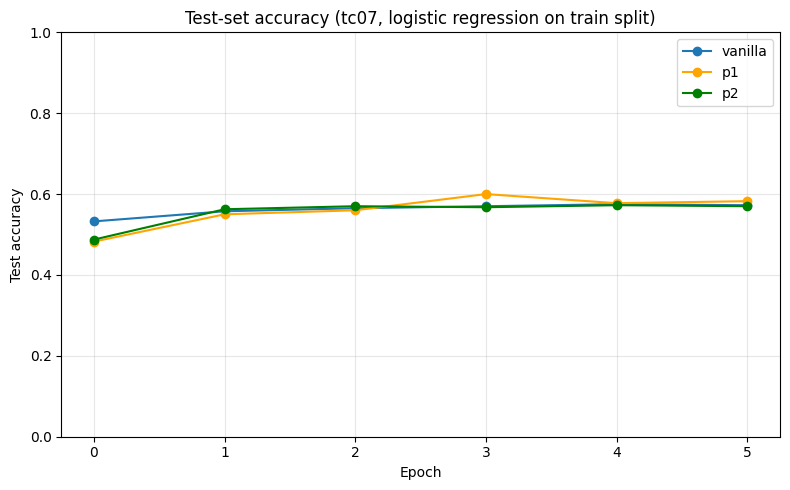

In [38]:
import numpy as np
from gensim.models import KeyedVectors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

SYNTHETIC_BASE = ROOT / "v1/synthetic_ontology" / TC_STR / "synthetic_ontology" / "1000"
TRAIN_LABELS = SYNTHETIC_BASE / "train_test" / "train.txt"
TEST_LABELS = SYNTHETIC_BASE / "train_test" / "test.txt"

assert TRAIN_LABELS.exists(), f"Train labels not found: {TRAIN_LABELS}"
assert TEST_LABELS.exists(), f"Test labels not found: {TEST_LABELS}"


def load_labeled_entities(path: Path) -> tuple[list[str], np.ndarray]:
    entities, labels = [], []
    for line in path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        entity, label = line.split("\t")
        entities.append(entity.strip("<>").strip())
        labels.append(int(label))
    return entities, np.array(labels, dtype=int)


def embeddings_for_entities(kv: KeyedVectors, entities: list[str], labels: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    vectors, kept_labels = [], []
    for entity, label in zip(entities, labels):
        if entity in kv:
            vectors.append(kv[entity])
            kept_labels.append(label)
    return np.asarray(vectors, dtype=np.float32), np.asarray(kept_labels, dtype=int)


def test_accuracy(kv_path: Path) -> tuple[float, int, int]:
    kv = KeyedVectors.load(str(kv_path), mmap=None)
    train_entities, train_labels = load_labeled_entities(TRAIN_LABELS)
    test_entities, test_labels = load_labeled_entities(TEST_LABELS)

    train_x, train_y = embeddings_for_entities(kv, train_entities, train_labels)
    test_x, test_y = embeddings_for_entities(kv, test_entities, test_labels)

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(train_x, train_y)
    predictions = clf.predict(test_x)
    return accuracy_score(test_y, predictions), len(test_y), len(test_labels)


def accuracy_curve(model_dir: Path, max_epoch: int = GRAPH_EPOCHS) -> tuple[list[int], list[float]]:
    epochs, accuracies = [], []
    for epoch in range(max_epoch + 1):
        kv_path = model_dir / f"epoch_{epoch}" / "model.kv"
        assert kv_path.exists(), f"Missing checkpoint: {kv_path}"
        acc, covered, total = test_accuracy(kv_path)
        epochs.append(epoch)
        accuracies.append(acc)
        print(f"{model_dir.name:>7} epoch {epoch}: acc={acc:.4f} ({covered}/{total} in vocab)")
    return epochs, accuracies


accuracy_curves = {
    "vanilla": VANILLA_OUT,
    "p1": FINETUNE_BASE / "p1",
    "p2": FINETUNE_BASE / "p2",
}
colors = {"vanilla": "C0", "p1": "orange", "p2": "green"}

fig, ax = plt.subplots(figsize=(8, 5))
for label, model_dir in accuracy_curves.items():
    print(f"\n=== {label} ===")
    epochs, accuracies = accuracy_curve(model_dir)
    ax.plot(epochs, accuracies, marker="o", label=label, color=colors[label])

ax.set_xlabel("Epoch")
ax.set_ylabel("Test accuracy")
ax.set_title(f"Test-set accuracy ({TC_STR}, logistic regression on train split)")
ax.set_xticks(range(0, GRAPH_EPOCHS + 1))
ax.set_ylim(0.0, 1.0)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()